# Use linear regression and random forest to predict Boston housing prices

## 1.Import the libraries and data

In [72]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [74]:
houseprice = pd.read_csv("Boston-house-price-data.csv")
houseprice.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### Variable Description
| Variable | Description |
|---|---|
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable, equal to 1 if tract bounds river and 0 otherwise |
| NOX | Nitric oxides concentration, measured in parts per 10 million |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built prior to 1940 |
| DIS | Weighted distances to five Boston employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate per \$10,000 |
| MEDV | Median value of owner-occupied homes, measured in \$1000s |

In [77]:
houseprice.shape

(506, 13)

## 2.Check for missing values in the dataset

In [80]:
houseprice.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

## 3.Divide the dataset into training and testing sets for model evaluation

In [83]:
houseprice_train, houseprice_test = train_test_split(houseprice,test_size=0.3,random_state=42)

In [85]:
houseprice_train.shape

(354, 13)

In [87]:
houseprice_test.shape

(152, 13)

## 4.Linear Regression Model

In [90]:
features_train = houseprice_train.drop("MEDV", axis=1)
price_train = houseprice_train["MEDV"]
features_test = houseprice_test.drop("MEDV", axis=1)
price_test = houseprice_test["MEDV"]

In [92]:
features_train_constant = sm.add_constant(features_train)
ols_model = sm.OLS(price_train, features_train_constant).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     78.44
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.35e-90
Time:                        15:09:20   Log-Likelihood:                -1060.1
No. Observations:                 354   AIC:                             2146.
Df Residuals:                     341   BIC:                             2197.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.5799      5.914      6.354      0.0

In [94]:
features_test_constant = sm.add_constant(features_test, has_constant="add")
price_predicted_ols = ols_model.predict(features_test_constant)

In [96]:
mae = mean_absolute_error(price_test, price_predicted_ols)
mse = mean_squared_error(price_test, price_predicted_ols)
rmse = np.sqrt(mse)
r2 = r2_score(price_test, price_predicted_ols)
print("MAE:", mae)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 3.1886622319425006
RMSE: 4.5951551240267925
R-squared: 0.7166209449097763


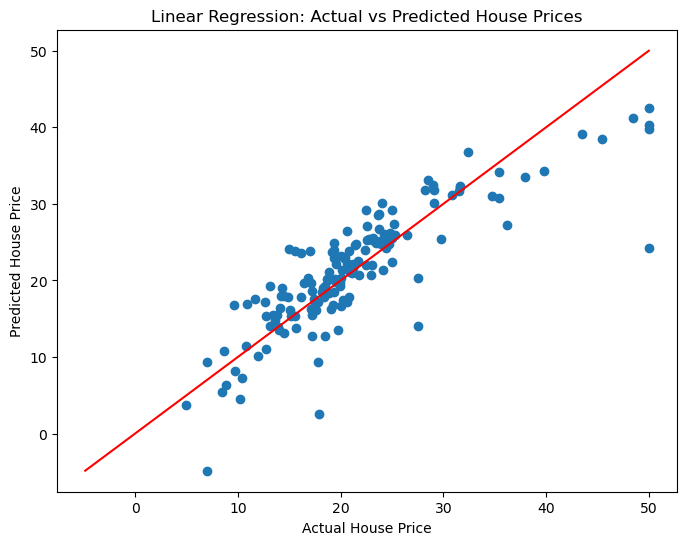

In [121]:
plt.figure(figsize=(8, 6))
plt.scatter(price_test, price_predicted_ols)
min_price = min(price_test.min(), price_predicted_ols.min())
max_price = max(price_test.max(), price_predicted_ols.max())
plt.plot([min_price, max_price], [min_price, max_price],color="red")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Linear Regression: Actual vs Predicted House Prices")
plt.savefig("figures/linear_regression_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## 5.Random Forest Model


In [101]:
random_forest_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [103]:
random_forest_model.fit(features_train, price_train)

RandomForestRegressor(random_state=42)

In [105]:
price_predicted_rf = random_forest_model.predict(features_test)

In [107]:
rf_mae = mean_absolute_error(price_test, price_predicted_rf)
rf_mse = mean_squared_error(price_test, price_predicted_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(price_test, price_predicted_rf)

print("Random Forest Regression")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R-squared:", rf_r2)

Random Forest Regression
MAE: 2.0683289473684217
RMSE: 3.1273646695445976
R-squared: 0.8687424042474825


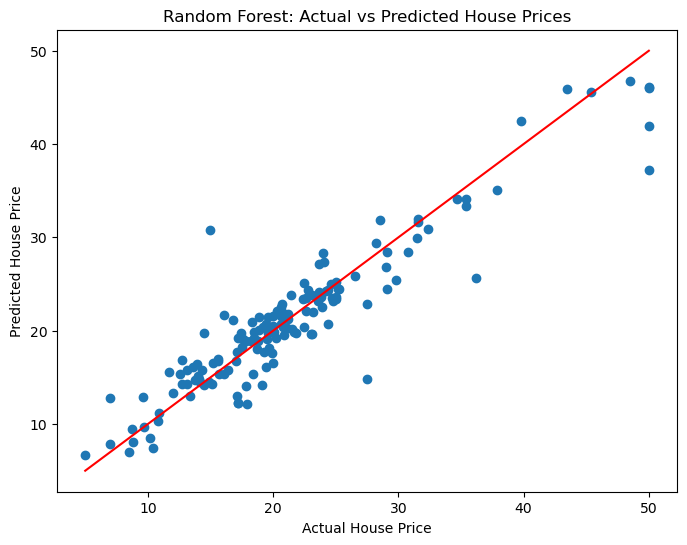

In [123]:
plt.figure(figsize=(8, 6))
plt.scatter(price_test, price_predicted_rf)
min_price = min(price_test.min(), price_predicted_rf.min())
max_price = max(price_test.max(), price_predicted_rf.max())
plt.plot([min_price, max_price],[min_price, max_price],color="red")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.savefig("figures/random_forest_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [113]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R-squared": [r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R-squared
0,Linear Regression,3.188662,4.595155,0.716621
1,Random Forest,2.068329,3.127365,0.868742


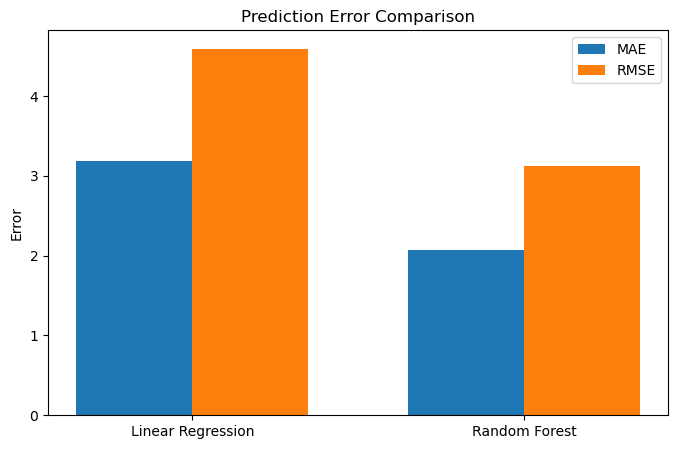

In [125]:
x = np.arange(len(comparison["Model"]))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison["MAE"], width, label="MAE")
plt.bar(x + width/2, comparison["RMSE"], width, label="RMSE")
plt.xticks(x, comparison["Model"])
plt.ylabel("Error")
plt.title("Prediction Error Comparison")
plt.legend()
plt.savefig("figures/prediction_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [119]:
feature_importance = pd.DataFrame({"Feature": features_train.columns, "Importance": random_forest_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance

,Feature,Importance
5,RM,0.441384
11,LSTAT,0.382217
7,DIS,0.067432
0,CRIM,0.034679
10,PTRATIO,0.020828
4,NOX,0.012772
6,AGE,0.012711
9,TAX,0.012326
2,INDUS,0.007716
8,RAD,0.004360


From the feature importance results, the model relies primarily on the variables RM and LSTAT when predicting house prices. RM represents the average number of rooms per dwelling; more rooms generally imply more living space and functionality, which is associated with higher house prices. LSTAT represents the percentage of lower-status population; a higher value indicates that the area tends to have lower income levels, meaning residents are generally able to afford lower housing prices, which is reflected in lower house values in those areas.